In [1]:
from pyspark.sql import *
from pyspark.sql.functions import *

from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
import pandas as pd

In [3]:
spark = SparkSession.builder.appName("House_price_prediction").master("local[*]").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/14 22:32:13 WARN Utils: Your hostname, Keshabs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.71 instead (on interface en0)
26/06/14 22:32:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 22:32:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/14 22:32:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
# Load data from Sklearn
from sklearn.datasets import fetch_california_housing

In [5]:
housing = fetch_california_housing()

In [6]:
df_pandas = pd.DataFrame(housing.data, columns=housing.feature_names)

df_pandas["MedHouseVal"] = housing.target

df_pandas

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [7]:
df = spark.createDataFrame(df_pandas)
df.show(5)

[Stage 0:>                                                          (0 + 1) / 1]

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|      4.526|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|      3.585|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|      3.521|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|      3.413|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25|      3.422|
+------+--------+------------------+------------------+---------

Traceback (most recent call last):
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
    ~~~~~~~~~~~~~^^
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

In [8]:
print(df.count())
print(len(df.columns))

20640
9


In [9]:
df.distinct().count()

20640

In [10]:
df_clean = df.distinct()

In [11]:
df_clean.describe("AveRooms").show()

+-------+------------------+
|summary|          AveRooms|
+-------+------------------+
|  count|             20640|
|   mean| 5.428999742190367|
| stddev|2.4741731394243214|
|    min|0.8461538461538461|
|    max| 141.9090909090909|
+-------+------------------+



In [12]:
df.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)



In [13]:
df_features = df_clean.withColumn(
    "RoomsPerHousehold",
    col("AveRooms")/col("AveBedrms")
).withColumn(
    "PopulationPerHousehold",
    col("Population")/col("AveOccup")
)

df_features.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)



In [14]:
feature_cols = [
    "MedInc" , "HouseAge", "AveRooms" ,"AveBedrms", "Population", "AveOccup" ,"Latitude","Longitude"
    ,"RoomsPerHousehold", "PopulationPerHousehold"
]

target_col = "MedHouseVal"

In [15]:
from pyspark.ml.feature import *

In [16]:
assembler = VectorAssembler(
    inputCols = feature_cols,
    outputCol = "features"
)

df_assembled = assembler.transform(df_features)
df_assembled.show(5)

+------+--------+-----------------+------------------+----------+------------------+--------+---------+-----------+-----------------+----------------------+--------------------+
|MedInc|HouseAge|         AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|RoomsPerHousehold|PopulationPerHousehold|            features|
+------+--------+-----------------+------------------+----------+------------------+--------+---------+-----------+-----------------+----------------------+--------------------+
|  3.12|    52.0|4.797527047913447| 1.061823802163833|    1157.0|1.7882534775888717|   37.84|  -122.25|      2.414|4.518195050946143|                 647.0|[3.12,52.0,4.7975...|
|7.0175|    37.0|6.982954545454546|1.0284090909090908|     420.0|2.3863636363636362|   37.82|   -122.2|      3.667|6.790055248618786|                 176.0|[7.0175,37.0,6.98...|
|5.8948|    52.0|7.740088105726873|1.0837004405286343|     585.0|2.5770925110132157|   37.83|  -122.24|      4

In [17]:
scaler = StandardScaler(
    inputCol = "features",
    outputCol = "scaledFeatures",
    withMean = True,
    withStd = True
)

scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

In [18]:
train_df, test_df = df_scaled.randomSplit([0.8, 0.2], seed=42)

In [19]:
train_df.count()

16560

In [20]:
lr = LinearRegression(
    featuresCol = "scaledFeatures",
    labelCol = target_col,
    maxIter = 100,
    regParam = 0.01
)
lr_model = lr.fit(train_df)
lr_model.intercept

26/06/14 22:32:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/06/14 22:32:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/14 22:32:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


2.0694427043316646

In [21]:
coefficients = lr_model.coefficients

for i in range(len(feature_cols)):
    feature = feature_cols[i]
    coeff = coefficients[i]
    print(feature + ": " + str(coeff))

MedInc: 0.8528782026322838
HouseAge: 0.1507656813789596
AveRooms: 0.1738795967026184
AveBedrms: -0.09034084316197433
Population: -0.3996773617500336
AveOccup: -0.0005009738414282418
Latitude: -0.7676491854026611
Longitude: -0.7244544789337868
RoomsPerHousehold: -0.24404296339769993
PopulationPerHousehold: 0.448920912396367


In [22]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)



In [23]:
lr_predictions.select("prediction").show(5)

+------------------+
|        prediction|
+------------------+
|0.6648682253413278|
|0.8896051628491817|
|1.1357381071441164|
|0.4911399466803259|
|0.9331499479322456|
+------------------+
only showing top 5 rows


In [24]:
lr_with_error = lr_predictions.withColumn(
    "Error",
    col(target_col) - col("prediction")
)

In [25]:
lr_with_error.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)
 |-- Error: double (nullable = true)



In [26]:
lr_with_error.select(
    col(target_col).alias("Actual Price"),
    col("prediction").alias("Predicted Price"),
    col("Error").alias("Residuals")
).show(10)

+------------+------------------+--------------------+
|Actual Price|   Predicted Price|           Residuals|
+------------+------------------+--------------------+
|       0.735|0.6648682253413278| 0.07013177465867215|
|       1.625|0.8896051628491817|  0.7353948371508183|
|       0.675|1.1357381071441164|-0.46073810714411634|
|       1.625|0.4911399466803259|   1.133860053319674|
|       0.875|0.9331499479322456|-0.05814994793224...|
|       1.113|0.7276692982495705|  0.3853307017504295|
|       1.344|0.9888095412740756|  0.3551904587259245|
|       1.042|  0.90573650150681| 0.13626349849319008|
|       0.818|1.0195557534607302| -0.2015557534607303|
|       1.531|0.5739967159084092|  0.9570032840915907|
+------------+------------------+--------------------+
only showing top 10 rows


In [27]:
evaluator_r2 = RegressionEvaluator(
    labelCol=target_col,
    predictionCol="prediction",
    metricName="r2"
)

lm_r2 = evaluator_r2.evaluate(lr_predictions)

print(lm_r2)
                                   

0.6454736092562379


In [28]:
import matplotlib.pyplot as plt
lr_pred_pandas = lr_predictions.select(
    col(target_col).alias("Actual"),
    col("prediction").alias("Predicted")
).toPandas()
lr_pred_pandas

,Actual,Predicted
0,0.73500,0.664868
1,1.62500,0.889605
2,0.67500,1.135738
3,1.62500,0.491140
4,0.87500,0.933150
...,...,...
4075,5.00001,6.832841
4076,5.00001,6.631838
4077,1.31300,7.237605
4078,5.00001,6.937296


In [29]:
lr_pred_pandas.head()

,Actual,Predicted
0,0.735,0.664868
1,1.625,0.889605
2,0.675,1.135738
3,1.625,0.491140
4,0.875,0.933150


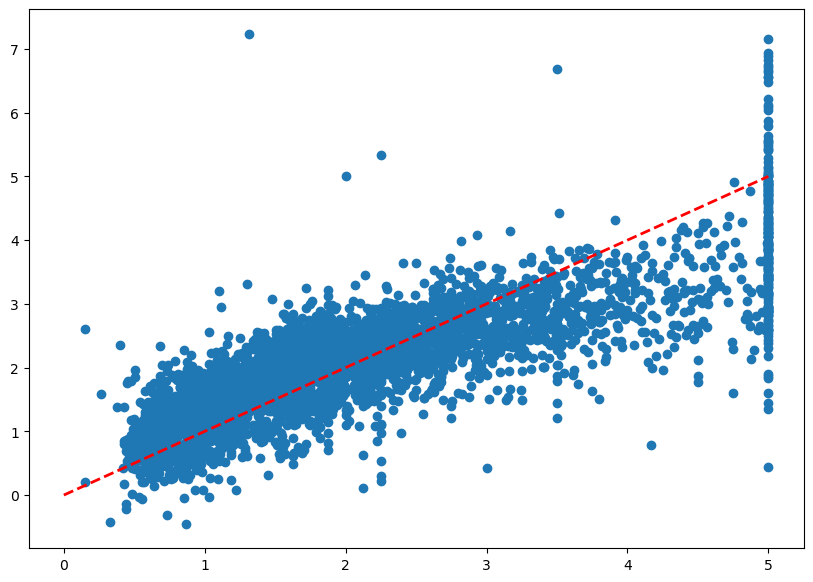

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(lr_pred_pandas["Actual"], lr_pred_pandas["Predicted"])

ax.plot([0, 5], [0, 5], "r--", lw=2)

plt.show()